# 실습 15: 언제부터 그랬는지 보기
- 상황: 이상한 줄은 찾았는데 그게 언제 나온 건지 모른다
- 목표: 시각을 되살려 흐름으로 감시하고, 조기 경보 목록으로 마감한다

## Step 0. 앞 실습까지 재현하기

In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# 1. 정제본 불러오기 (day02 실습 결과물)
df = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv")

# 2. 센서 열의 빈칸을 그 열의 중앙값으로 채우기
센서열 = [c for c in df.columns if c.startswith("sensor_")]
df[센서열] = df[센서열].fillna(df[센서열].median())

# 3. 입력은 센서 열만, 정답은 불량이면 1
X = df[센서열]
정답 = (df["result"] == "불량").astype(int)

# 4. 고립시키기로 지목하기 - 실습 13·14와 같은 설정
탐지기 = IsolationForest(contamination=0.05, random_state=42)
지목 = 탐지기.fit_predict(X)          # 정답은 넣지 않는다
이상탐지 = (지목 == -1)               # 이상이라 한 자리만 참

print("전체 행 수:", len(df))
print("이상탐지 건수:", int(이상탐지.sum()), "건")
print("그중 불량:", int((이상탐지 & (정답 == 1)).sum()), "건")

전체 행 수: 1567
이상탐지 건수: 79 건
그중 불량: 12 건


## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 흐름으로 보는 말

| 수업에서 쓰는 말 | 정식 이름 | 뜻 |
|---|---|---|
| 시계열 | time series | 시간 순서가 있는 기록. 앞뒤가 이어져 있어서 순서를 바꾸면 뜻이 달라진다 |
| 이동평균 | 이동평균 (moving average) | 최근 몇 개의 평균. 들쭉날쭉한 걸 눌러서 흐름만 남긴다 |
| 관리도 | 관리도 (control chart) | 평소 범위를 선으로 그려두고 넘는 순간을 잡는 그림 |
| 관리 한계선 | 관리상한 UCL / 관리하한 LCL | 그 선. 흔히 평균에서 표준편차의 세 배만큼 위아래로 긋는다 |
| 이탈 | 관리 이탈 (out of control) | 관리 한계선을 넘은 것 |
| 관리도로 공정을 지켜보는 일 | 통계적 공정관리 (SPC) | 현장에서 백 년 가까이 써온 방법. 면접에서 이 이름으로 묻는다 |

## Step 2. 떨어져 나간 시각 다시 붙이기

In [2]:
import pandas as pd

# ① 파일을 불러오는 것 - 첫날부터 계속 쓴 것
원본 = pd.read_csv("../../data/04_secom.csv")

# ② 글자로 된 시각을 날짜로 바꿔주는 것
# ③ 표기가 섞여 있어도 알아서 읽으라는 뜻. 안 넣으면 오류가 난다
df["측정시각"] = pd.to_datetime(원본["measured_at"], format="mixed")

# 붙이기 전에 확인 - 두 파일의 행 순서가 같아야 붙일 수 있다
# ④ 전부 참일 때만 참이 되는 것
print("정제본 행 수:", len(df), "/ 원본 행 수:", len(원본))
print("답이 전부 같은가:", (df["result"].values == 원본["result"].values).all())

# ⑤ 그 열 기준으로 줄을 세우는 것
# ⑥ 옛 번호를 버리라는 뜻
df = df.sort_values("측정시각").reset_index(drop=True)

print("기간:", df["측정시각"].min(), "~", df["측정시각"].max())

정제본 행 수: 1567 / 원본 행 수: 1567
답이 전부 같은가: True
기간: 2008-01-08 02:02:00 ~ 2008-12-10 18:47:00


## Step 4. 월별로 보면

In [3]:
# 시각에서 달만 떼어낸다 - 2008-01-08 02:02 -> 2008-01
df["월"] = df["측정시각"].dt.to_period("M")

# 정렬된 df 에서 바로 센다
# (앞 칸의 정답·이상탐지는 정렬 전 순서라 지금 df 와 줄이 어긋난다. 여기서는 쓰지 않는다)
월별 = df.groupby("월").agg(
    전체건수=("result", "size"),
    불량건수=("result", lambda 판정: (판정 == "불량").sum()),
)
월별["불량률(%)"] = (월별["불량건수"] / 월별["전체건수"] * 100).round(2)

print(월별)
print()

# idxmax / idxmin - 가장 큰(작은) 값이 있는 줄의 이름을 돌려준다
높은달 = 월별["불량률(%)"].idxmax()
낮은달 = 월별["불량률(%)"].idxmin()
print(f"가장 높은 달: {높은달} ({월별.loc[높은달, '불량률(%)']} %, {월별.loc[높은달, '전체건수']}건 중 {월별.loc[높은달, '불량건수']}건)")
print(f"가장 낮은 달: {낮은달} ({월별.loc[낮은달, '불량률(%)']} %, {월별.loc[낮은달, '전체건수']}건 중 {월별.loc[낮은달, '불량건수']}건)")

         전체건수  불량건수  불량률(%)
월                          
2008-01    51     3    5.88
2008-02    98     5    5.10
2008-03    50     1    2.00
2008-04    49     3    6.12
2008-05    62     7   11.29
2008-06    67     6    8.96
2008-07   114    16   14.04
2008-08   471    38    8.07
2008-09   413    17    4.12
2008-10   123     6    4.88
2008-11    35     2    5.71
2008-12    34     0    0.00

가장 높은 달: 2008-07 (14.04 %, 114건 중 16건)
가장 낮은 달: 2008-12 (0.0 %, 34건 중 0건)


## Step 5. 흐름 보고 관리선 긋기

In [4]:
# 볼 센서 하나를 고른다
센서 = "sensor_039"

# ⑦ 창문을 미끄러뜨리며 묶어주는 것
# ⑧ 몇 개씩 묶을지 정하는 자리
# ⑨ 묶은 것들의 평균을 내는 것
df["이동평균"] = df[센서].rolling(window=20).mean()

# 평소 범위를 정한다. 첫날에 한 그 방법이다
# ⑩ 값들이 평균에서 얼마나 벌어져 있는지 재는 것
평균 = df[센서].mean()
표준편차 = df[센서].std()

# ⑪ 평균에서 표준편차의 몇 배만큼 그을지
상한 = 평균 + 3 * 표준편차
하한 = 평균 - 3 * 표준편차

print(f"평균 {평균:.2f} / 표준편차 {표준편차:.2f}")
print(f"관리 상한 {상한:.2f} / 관리 하한 {하한:.2f}")

# ⑫ 위로 넘었거나 아래로 넘었거나 - 한쪽만 참이어도 참인 기호
df["이탈"] = (df[센서] > 상한) | (df[센서] < 하한)

# 불량 표시를 df 안에서 다시 만든다
df["불량여부"] = (df["result"] == "불량").astype(int)

print("이탈:", df["이탈"].sum(), "건 / 그중 불량", (df["이탈"] & (df["불량여부"] == 1)).sum(), "건")

평균 86.84 / 표준편차 0.45
관리 상한 88.18 / 관리 하한 85.50
이탈: 71 건 / 그중 불량 15 건


### 문법 노트 - 흐름과 관리선

선을 넘었는지 볼 때 두 조건을 묶는다.

    위로 넘었거나 아래로 넘었거나  ->  |

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ⑦ | `rolling` | 창문을 미끄러뜨리며 묶는다 | 새로 배움 |
| ⑧ | `window` | 몇 개씩 묶을지 정하는 자리 | 새로 배움 |
| ⑨ | `.mean()` | 묶은 것들의 평균 | 첫날부터 쓴 것 |
| ⑩ | `.std()` | 표준편차 - 평균에서 얼마나 벌어져 있나 | 첫날 관리선·지난주 흔들림에서 썼다 |
| ⑪ | `3` | 표준편차의 세 배로 선을 긋는다 | 첫날에 정한 그 배수 |
| ⑫ | `\|` | 한쪽이라도 참이면 참 | 앞 실습에서 배웠다 |

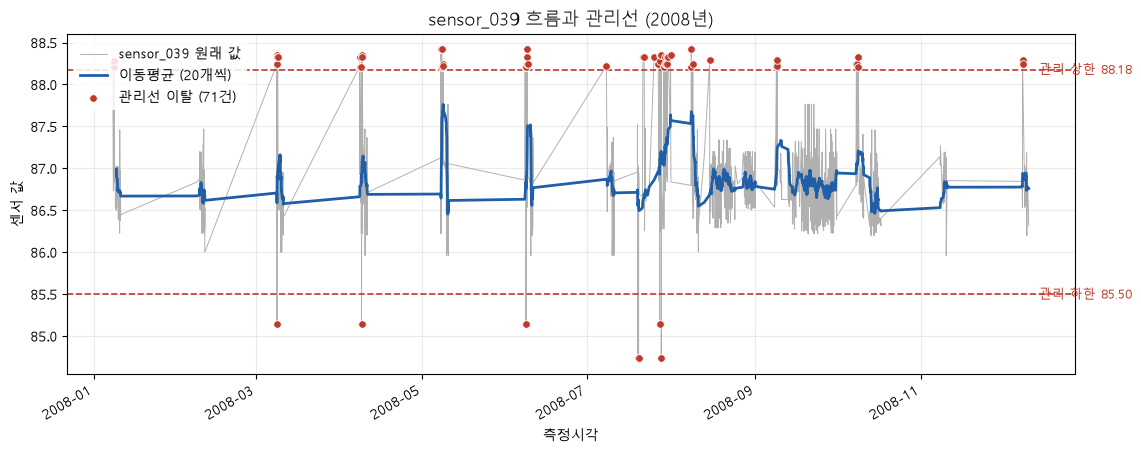

저장함: results\sensor_trend.png


In [5]:
from pathlib import Path
import matplotlib.pyplot as plt

# 한글이 네모(□)로 깨지지 않게 글꼴을 지정한다 (윈도우 기본 한글 글꼴)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 깨지는 것 방지

시각 = df["측정시각"]
값 = df[센서]

# figsize=(가로, 세로) - 점이 1567개라 넓어야 보인다
fig, ax = plt.subplots(figsize=(13, 5))

# 원래 값은 옅은 회색으로 깔아둔다
ax.plot(시각, 값, color="#b0b0b0", linewidth=0.7, label=f"{센서} 원래 값")

# 이동평균은 진하게 - 들쭉날쭉한 것을 눌러 흐름만 남긴 선
ax.plot(시각, df["이동평균"], color="#1f5fa8", linewidth=2, label="이동평균 (20개씩)")

# 관리 상한·하한을 가로선으로. axhline - 가로로 쭉 뻗는 선 (h는 horizontal)
ax.axhline(상한, color="#c0392b", linestyle="--", linewidth=1.2)
ax.axhline(하한, color="#c0392b", linestyle="--", linewidth=1.2)

# 선에 이름표를 직접 붙인다 - 범례를 찾아보지 않아도 알아보게
ax.text(시각.iloc[-1], 상한, f"  관리 상한 {상한:.2f}",
        color="#c0392b", va="center", fontsize=9)
ax.text(시각.iloc[-1], 하한, f"  관리 하한 {하한:.2f}",
        color="#c0392b", va="center", fontsize=9)

# 선을 넘은 지점만 점으로 덧그린다. zorder - 클수록 위에 그린다
ax.scatter(시각[df["이탈"]], 값[df["이탈"]],
           color="#c0392b", s=30, zorder=5,
           edgecolor="white", linewidth=0.6,
           label=f"관리선 이탈 ({int(df['이탈'].sum())}건)")

ax.set_title(f"{센서} 흐름과 관리선 (2008년)", fontsize=13)
ax.set_xlabel("측정시각")
ax.set_ylabel("센서 값")
# 범례가 선 위에 겹치므로 흰 배경을 깔아 글자가 묻히지 않게 한다
ax.legend(loc="upper left", facecolor="white", edgecolor="none", framealpha=0.85)
ax.grid(alpha=0.25)                       # 눈금선은 옅게 - 데이터가 주인공
fig.autofmt_xdate()                       # 날짜가 겹치지 않게 비스듬히

# 파일로 저장한다
저장폴더 = Path("results")
저장폴더.mkdir(exist_ok=True)
fig.savefig(저장폴더 / "sensor_trend.png", dpi=150, bbox_inches="tight")

plt.show()
print("저장함:", 저장폴더 / "sensor_trend.png")

In [6]:
from sklearn.ensemble import IsolationForest

# df 에는 아직 이상탐지 열이 없다.
# Step 0 의 이상탐지는 정렬 전 순서라 그대로 붙이면 줄이 어긋난다 - 지금 df 순서로 다시 지목한다
센서열 = [c for c in df.columns if c.startswith("sensor_")]
탐지기 = IsolationForest(contamination=0.05, random_state=42)
df["이상탐지"] = (탐지기.fit_predict(df[센서열]) == -1)

# 걸린 근거를 줄마다 적는다
df["근거"] = ""
df.loc[df["이상탐지"] & ~df["이탈"], "근거"] = "이상탐지"
df.loc[~df["이상탐지"] & df["이탈"], "근거"] = "관리선"
df.loc[df["이상탐지"] & df["이탈"], "근거"] = "둘 다"

# 둘 중 하나라도 걸린 줄만 모은다
경보목록 = df[df["이상탐지"] | df["이탈"]].copy()

# 둘 다 걸린 줄을 맨 위로, 나머지는 시간 순서로
경보목록["순위"] = (경보목록["근거"] != "둘 다").astype(int)
경보목록 = 경보목록.sort_values(["순위", "측정시각"]).reset_index(drop=True)

print("조기 경보 목록:", len(경보목록), "건")
print(경보목록["근거"].value_counts().to_string())
print()
print("맨 위 10건")
print(경보목록[["측정시각", "근거", 센서, "불량여부"]].head(10).to_string(index=False))
print()

# ---------- 표 ----------
둘다 = df["이상탐지"] & df["이탈"]
둘중하나 = df["이상탐지"] | df["이탈"]
전체불량 = int(df["불량여부"].sum())

def 한줄(이름, 표시):
    건수 = int(표시.sum())
    잡은것 = int((표시 & (df["불량여부"] == 1)).sum())
    print(f"{이름:<14} | {건수:>6} 건 | {잡은것:>5} 건 | {잡은것 / 건수 * 100:>9.2f} %")

print("구분           |   건수 | 그중 불량 | 지목 중 진짜")
print("-" * 52)
한줄("둘 다", 둘다)
한줄("둘 중 하나라도", 둘중하나)
print("-" * 52)
print("이 목록으로 못 잡은 불량:", 전체불량 - int((둘중하나 & (df["불량여부"] == 1)).sum()), "건")
print(f"전체 불량률: {df['불량여부'].mean() * 100:.2f} %  (전체 {len(df)} 건 중 불량 {전체불량} 건)")

조기 경보 목록: 123 건
근거
이상탐지    52
관리선     44
둘 다     27

맨 위 10건
               측정시각  근거  sensor_039  불량여부
2008-03-08 13:09:00 둘 다     88.2425     0
2008-04-08 03:49:00 둘 다     88.3282     0
2008-04-08 18:24:00 둘 다     85.1414     0
2008-04-08 20:58:00 둘 다     88.3548     1
2008-04-08 23:33:00 둘 다     88.3312     0
2008-05-08 07:48:00 둘 다     88.4188     0
2008-06-08 09:57:00 둘 다     85.1414     0
2008-06-08 21:15:00 둘 다     88.2425     0
2008-06-08 22:27:00 둘 다     88.3282     0
2008-07-19 21:57:00 둘 다     84.7327     1

구분           |   건수 | 그중 불량 | 지목 중 진짜
----------------------------------------------------
둘 다            |     27 건 |     8 건 |     29.63 %
둘 중 하나라도       |    123 건 |    19 건 |     15.45 %
----------------------------------------------------
이 목록으로 못 잡은 불량: 85 건
전체 불량률: 6.64 %  (전체 1567 건 중 불량 104 건)


## Step 6. 조기 경보 리포트

| 걸린 근거 | 건수 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 둘 다 | [27] | [8] | [29.6%] |
| 둘 중 하나라도 | [123] | [19] | [15.4%] |
| (견줄 값) 전체 불량률 | 1567 | [104] | [6.64%] |

- 먼저 열어볼 것 : [둘 다 걸린 27건. 전체 불량률의 네 배 반이라 여기부터 본다]
- 무엇을 근거로 : [이상탐지 두 방법이 같이 짚었고, 관리선도 넘었다]
- 놓친 것 : [불량 104건 중 85건은 이 목록에 없다]
- 아직 못 미더운 점 : [관리선은 센서 하나만 봤다. 나머지 마흔아홉 개는 안 봤다]
- 다음에 해볼 것 : [센서를 더 골라 관리선을 긋고 겹치는지 본다]

---
## 직접 해보기 (도전) - 센서를 더 보면 달라지나

- 상황: 관리선을 센서 하나에만 그었다. 더 그으면 어떻게 될까
- 할 일: 센서를 여러 개 골라 관리선을 긋고, 몇 개나 넘었는지로 순위를 매긴다
- 결과물: 다섯 줄짜리 표 1개 + 한 줄 메모

In [7]:
# 센서 50개에 각각 평균 ± 3 표준편차로 관리선을 긋고, 몇 건이 넘는지 세어본다
센서열 = [c for c in df.columns if c.startswith("sensor_")]

이탈건수 = {}
for 센서이름 in 센서열:
    평균값 = df[센서이름].mean()
    표준편차값 = df[센서이름].std()
    넘음 = (df[센서이름] > 평균값 + 3 * 표준편차값) | (df[센서이름] < 평균값 - 3 * 표준편차값)
    이탈건수[센서이름] = int(넘음.sum())

# 20건 이상 100건 이하인 센서만 남긴다
# (너무 적으면 볼 게 없고, 너무 많으면 관리선이 제 구실을 못 한다는 뜻)
후보 = [이름 for 이름 in 센서열 if 20 <= 이탈건수[이름] <= 100]
print("조건에 맞는 센서:", len(후보), "개")
print({이름: 이탈건수[이름] for 이름 in 후보})

# 그중 다섯 개를 고른다 - 열 순서 앞에서부터. 정답을 보고 고르지 않는다
고른센서 = 후보[:5]
print()
print("고른 센서:", 고른센서)
print()

# 줄마다 몇 개의 센서에서 선을 넘었는지 센다
df["경보수"] = 0
for 센서이름 in 고른센서:
    평균값 = df[센서이름].mean()
    표준편차값 = df[센서이름].std()
    넘음 = (df[센서이름] > 평균값 + 3 * 표준편차값) | (df[센서이름] < 평균값 - 3 * 표준편차값)
    df["경보수"] = df["경보수"] + 넘음.astype(int)

# ---------- 표 ----------
구간들 = [("0개", df["경보수"] == 0),
          ("1개", df["경보수"] == 1),
          ("2개", df["경보수"] == 2),
          ("3개 이상", df["경보수"] >= 3)]

print("경보수     | 그런 줄 | 그중 불량 | 지목 중 진짜")
print("-" * 50)
for 이름, 표시 in 구간들:
    건수 = int(표시.sum())
    잡은것 = int((표시 & (df["불량여부"] == 1)).sum())
    비율 = f"{잡은것 / 건수 * 100:>9.2f} %" if 건수 else "        - "
    print(f"{이름:<10} | {건수:>5} 건 | {잡은것:>5} 건 | {비율}")
print("-" * 50)
print(f"전체 불량률: {df['불량여부'].mean() * 100:.2f} %  (전체 {len(df)} 건 중 불량 {int(df['불량여부'].sum())} 건)")

조건에 맞는 센서: 18 개
{'sensor_511': 32, 'sensor_432': 32, 'sensor_431': 32, 'sensor_022': 24, 'sensor_211': 28, 'sensor_164': 32, 'sensor_161': 54, 'sensor_027': 39, 'sensor_248': 47, 'sensor_160': 35, 'sensor_080': 21, 'sensor_065': 23, 'sensor_023': 27, 'sensor_469': 23, 'sensor_127': 26, 'sensor_039': 71, 'sensor_033': 27, 'sensor_574': 60}

고른 센서: ['sensor_511', 'sensor_432', 'sensor_431', 'sensor_022', 'sensor_211']

경보수     | 그런 줄 | 그중 불량 | 지목 중 진짜
--------------------------------------------------
0개         |  1478 건 |    86 건 |      5.82 %
1개         |    57 건 |    11 건 |     19.30 %
2개         |     8 건 |     1 건 |     12.50 %
3개 이상      |    24 건 |     6 건 |     25.00 %
--------------------------------------------------
전체 불량률: 6.64 %  (전체 1567 건 중 불량 104 건)


---
## 더 해보기 - 흐름이 선을 넘은 구간 찾기

- 상황: 점 하나가 튄 것보다, 흐름이 한동안 벗어난 구간이 더 무섭다
- 할 일: 이동평균 자체의 평균·표준편차로 선을 긋고(2 표준편차), 이어진 구간을 묶는다
- 결과물: 구간 표 1개 + 구간을 칠한 그림 1장

이동평균의 평균 86.835 / 표준편차 0.193
2 표준편차 선 - 상한 87.221 / 하한 86.449
넘은 줄: 77 건  (이동평균이 아직 없는 줄 19 건은 제외)

넘은 구간: 5 개

구간 |               시작 |                 끝 | 건수 | 불량 | 불량률
------------------------------------------------------------------------------
   1 | 2008-05-08 07:12:00 | 2008-05-10 04:48:00 |   21 |    2 |   9.52 %
   2 | 2008-06-08 20:17:00 | 2008-06-10 04:26:00 |   15 |    2 |  13.33 %
   3 | 2008-07-29 15:49:00 | 2008-07-29 15:49:00 |    1 |    1 | 100.00 %
   4 | 2008-07-29 21:07:00 | 2008-08-09 04:21:00 |   27 |    5 |  18.52 %
   5 | 2008-09-08 23:34:00 | 2008-09-13 00:25:00 |   13 |    2 |  15.38 %
------------------------------------------------------------------------------
구간 안 합계: 77 건 / 불량 12 건 / 15.58 %
전체 불량률 : 6.64 %


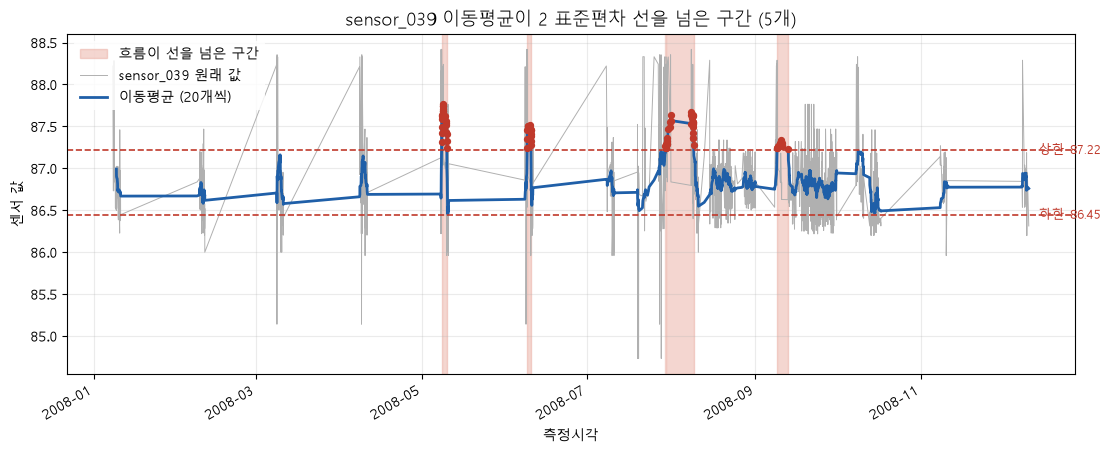

저장함: results\sensor_trend_zones.png


In [8]:
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 원래 값이 아니라 흐름(이동평균) 자체의 평균과 표준편차로 선을 다시 긋는다
흐름 = df["이동평균"]
흐름평균 = 흐름.mean()
흐름표준편차 = 흐름.std()
흐름상한 = 흐름평균 + 2 * 흐름표준편차
흐름하한 = 흐름평균 - 2 * 흐름표준편차

print(f"이동평균의 평균 {흐름평균:.3f} / 표준편차 {흐름표준편차:.3f}")
print(f"2 표준편차 선 - 상한 {흐름상한:.3f} / 하한 {흐름하한:.3f}")

# 앞 19칸은 이동평균이 아직 없다(NaN). 넘지 않은 것으로 둔다
넘음 = ((흐름 > 흐름상한) | (흐름 < 흐름하한)).fillna(False)
print("넘은 줄:", int(넘음.sum()), "건  (이동평균이 아직 없는 줄", int(흐름.isna().sum()), "건은 제외)")
print()

# 이어진 줄끼리 한 구간으로 묶는다 - 값이 바뀌는 자리마다 번호가 올라간다
구간번호 = (넘음 != 넘음.shift()).cumsum()
구간들 = [묶음 for 번호, 묶음 in df[넘음].groupby(구간번호[넘음])]

print("넘은 구간:", len(구간들), "개")
print()
print("구간 |               시작 |                 끝 | 건수 | 불량 | 불량률")
print("-" * 78)
for 번호, 묶음 in enumerate(구간들, 1):
    불량 = int(묶음["불량여부"].sum())
    시작 = 묶음["측정시각"].min()
    끝 = 묶음["측정시각"].max()
    print(f"{번호:>4} | {시작} | {끝} | {len(묶음):>4} | {불량:>4} | {불량 / len(묶음) * 100:>6.2f} %")
print("-" * 78)

구간안 = 넘음
구간안건수 = int(구간안.sum())
구간안불량 = int(df.loc[구간안, "불량여부"].sum())
print(f"구간 안 합계: {구간안건수} 건 / 불량 {구간안불량} 건 / {구간안불량 / 구간안건수 * 100:.2f} %")
print(f"전체 불량률 : {df['불량여부'].mean() * 100:.2f} %")

# ---------- 그림 ----------
시각 = df["측정시각"]
값 = df[센서]

fig, ax = plt.subplots(figsize=(13, 5))

# 구간을 먼저 칠한다 - 선보다 아래에 깔리도록
for 번호, 묶음 in enumerate(구간들):
    ax.axvspan(묶음["측정시각"].min(), 묶음["측정시각"].max(),
               color="#e8a598", alpha=0.45, zorder=0,
               label="흐름이 선을 넘은 구간" if 번호 == 0 else None)

ax.plot(시각, 값, color="#b0b0b0", linewidth=0.7, label=f"{센서} 원래 값")
ax.plot(시각, 흐름, color="#1f5fa8", linewidth=2, label="이동평균 (20개씩)")

# 이동평균에 그은 2 표준편차 선
ax.axhline(흐름상한, color="#c0392b", linestyle="--", linewidth=1.2)
ax.axhline(흐름하한, color="#c0392b", linestyle="--", linewidth=1.2)
ax.text(시각.iloc[-1], 흐름상한, f"  상한 {흐름상한:.2f}", color="#c0392b", va="center", fontsize=9)
ax.text(시각.iloc[-1], 흐름하한, f"  하한 {흐름하한:.2f}", color="#c0392b", va="center", fontsize=9)

# 구간이 한두 줄뿐이면 칠한 띠가 너무 얇아 안 보이므로 점으로도 찍는다
ax.scatter(시각[넘음], 흐름[넘음], color="#c0392b", s=18, zorder=5)

ax.set_title(f"{센서} 이동평균이 2 표준편차 선을 넘은 구간 ({len(구간들)}개)", fontsize=13)
ax.set_xlabel("측정시각")
ax.set_ylabel("센서 값")
ax.legend(loc="upper left", facecolor="white", edgecolor="none", framealpha=0.85)
ax.grid(alpha=0.25)
fig.autofmt_xdate()

저장폴더 = Path("results")
저장폴더.mkdir(exist_ok=True)
fig.savefig(저장폴더 / "sensor_trend_zones.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장함:", 저장폴더 / "sensor_trend_zones.png")